In [3]:
# Cell 1: Imports and settings
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

RANDOM_STATE = 42

In [ ]:
train_path = "train.json"
test_path = "test.json" 

In [ ]:
def load_json_records(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path.resolve()}")

    with open(path, "r", encoding="utf-8") as f:
        first_char = f.read(1)
        f.seek(0)
        if first_char == "[":
            data = json.load(f)
        else:
            data = [json.loads(line) for line in f if line.strip()]
    return pd.DataFrame(data)

train_df = load_json_records(train_path)
print("Train shape:", train_df.shape)
train_df.head()

Train shape: (4040, 32)


,giver_username_if_known,number_of_downvotes_of_request_at_retrieval,number_of_upvotes_of_request_at_retrieval,post_was_edited,request_id,request_number_of_comments_at_retrieval,request_text,request_text_edit_aware,request_title,requester_account_age_in_days_at_request,requester_account_age_in_days_at_retrieval,requester_days_since_first_post_on_raop_at_request,requester_days_since_first_post_on_raop_at_retrieval,requester_number_of_comments_at_request,requester_number_of_comments_at_retrieval,requester_number_of_comments_in_raop_at_request,requester_number_of_comments_in_raop_at_retrieval,requester_number_of_posts_at_request,requester_number_of_posts_at_retrieval,requester_number_of_posts_on_raop_at_request,requester_number_of_posts_on_raop_at_retrieval,requester_number_of_subreddits_at_request,requester_received_pizza,requester_subreddits_at_request,requester_upvotes_minus_downvotes_at_request,requester_upvotes_minus_downvotes_at_retrieval,requester_upvotes_plus_downvotes_at_request,requester_upvotes_plus_downvotes_at_retrieval,requester_user_flair,requester_username,unix_timestamp_of_request,unix_timestamp_of_request_utc
0,N/A,0,1,False,t3_l25d7,0,Hi I am in need of food for my 4 children we are a military family that has really hit hard times and we have exahusted all means of help just to be able to feed my family and make it through anot...,Hi I am in need of food for my 4 children we are a military family that has really hit hard times and we have exahusted all means of help just to be able to feed my family and make it through anot...,Request Colorado Springs Help Us Please,0.000000,792.420405,0.000000,792.420405,0,0,0,0,0,1,0,1,0,False,[],0,1,0,1,None,nickylvst,1.317853e+09,1.317849e+09
1,N/A,2,5,False,t3_rcb83,0,I spent the last money I had on gas today. Im broke until next Thursday :(,I spent the last money I had on gas today. Im broke until next Thursday :(,"[Request] California, No cash and I could use some dinner",501.111100,1122.279838,0.000000,621.127072,0,1000,0,0,15,26,0,2,12,False,"[AskReddit, Eve, IAmA, MontereyBay, RandomKindness, RedditBiography, dubstep, gamecollecting, gaming, halo, i18n, techsupport]",34,4258,116,11168,None,fohacidal,1.332652e+09,1.332649e+09
2,N/A,0,3,False,t3_lpu5j,0,My girlfriend decided it would be a good idea to get off at Perth bus station when she was coming to visit me and has since had to spend all her money on a taxi to get to me here in Dundee. Any ch...,My girlfriend decided it would be a good idea to get off at Perth bus station when she was coming to visit me and has since had to spend all her money on a taxi to get to me here in Dundee. Any ch...,"[Request] Hungry couple in Dundee, Scotland would love some pizza!",0.000000,771.616181,0.000000,771.616181,0,0,0,0,0,1,0,1,0,False,[],0,3,0,3,None,jacquibatman7,1.319650e+09,1.319646e+09
3,N/A,0,1,True,t3_mxvj3,4,"It's cold, I'n hungry, and to be completely honest I'm broke. My mum said we're having leftovers for dinner. A random pizza arriving would be nice.\n\nEdit: We had leftovers.","It's cold, I'n hungry, and to be completely honest I'm broke. My mum said we're having leftovers for dinner. A random pizza arriving would be nice.\n\nEdit: We had leftovers.","[Request] In Canada (Ontario), just got home from school. Need pizza.",6.518438,741.035602,0.000000,734.517164,36,41,0,2,1,2,0,1,4,False,"[AskReddit, DJs, IAmA, Random_Acts_Of_Pizza]",54,59,76,81,None,4on_the_floor,1.322855e+09,1.322855e+09
4,N/A,6,6,False,t3_1i6486,5,"hey guys:\n I love this sub. I think it's great. (Except the sob stories. I miss when this place was fun!) Anywho, I've given a pizza out before so thought I would try my luck at getting one. My f...","hey guys:\n I love this sub. I think it's great. (Except the sob stories. I miss when this place was fun!) Anywho, I've given a pizza out before so thought I would try my luck at getting one. My f...",[Request] Old friend coming to visit. Would LOVE to feed her some dinner. Indiana,162.063252,308.633819,101

In [ ]:
if Path(test_path).exists():
    test_df = load_json_records(test_path)
    print("Test shape:", test_df.shape)
else:
    test_df = None
    print("No test file found. Continuing with training data only.")

Test shape: (1631, 17)


In [ ]:
print("Columns:")
print(sorted(train_df.columns.tolist()))

Columns:
['giver_username_if_known', 'number_of_downvotes_of_request_at_retrieval', 'number_of_upvotes_of_request_at_retrieval', 'post_was_edited', 'request_id', 'request_number_of_comments_at_retrieval', 'request_text', 'request_text_edit_aware', 'request_title', 'requester_account_age_in_days_at_request', 'requester_account_age_in_days_at_retrieval', 'requester_days_since_first_post_on_raop_at_request', 'requester_days_since_first_post_on_raop_at_retrieval', 'requester_number_of_comments_at_request', 'requester_number_of_comments_at_retrieval', 'requester_number_of_comments_in_raop_at_request', 'requester_number_of_comments_in_raop_at_retrieval', 'requester_number_of_posts_at_request', 'requester_number_of_posts_at_retrieval', 'requester_number_of_posts_on_raop_at_request', 'requester_number_of_posts_on_raop_at_retrieval', 'requester_number_of_subreddits_at_request', 'requester_received_pizza', 'requester_subreddits_at_request', 'requester_upvotes_minus_downvotes_at_request', 'reques

In [ ]:
train_df.dtypes.sort_index()

giver_username_if_known                                  object
number_of_downvotes_of_request_at_retrieval               int64
number_of_upvotes_of_request_at_retrieval                 int64
post_was_edited                                          object
request_id                                               object
request_number_of_comments_at_retrieval                   int64
request_text                                             object
request_text_edit_aware                                  object
request_title                                            object
requester_account_age_in_days_at_request                float64
requester_account_age_in_days_at_retrieval              float64
requester_days_since_first_post_on_raop_at_request      float64
requester_days_since_first_post_on_raop_at_retrieval    float64
requester_number_of_comments_at_request                   int64
requester_number_of_comments_at_retrieval                 int64
requester_number_of_comments_in_raop_at_

In [ ]:
missing_pct = (train_df.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0].round(2)

requester_user_flair    75.4
dtype: float64

In [ ]:
TARGET = "requester_received_pizza"

if TARGET not in train_df.columns:
    raise ValueError(f"Target column '{TARGET}' not found.")

train_df[TARGET].value_counts(dropna=False)

requester_received_pizza
False    3046
True      994
Name: count, dtype: int64

In [ ]:
train_df[TARGET].value_counts(normalize=True, dropna=False).round(4)

requester_received_pizza
False    0.754
True     0.246
Name: proportion, dtype: float64

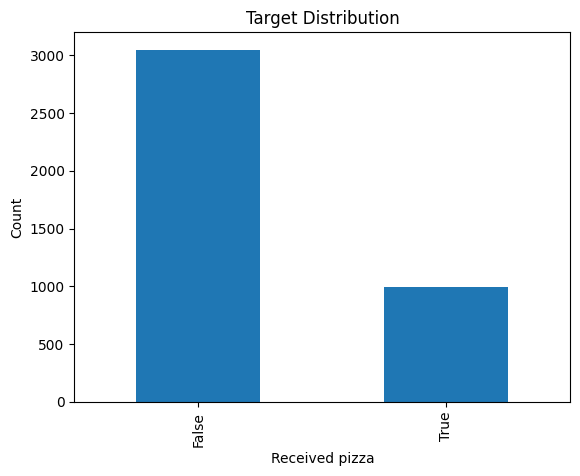

In [ ]:
train_df[TARGET].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Received pizza")
plt.ylabel("Count")
plt.show()

In [ ]:
potential_leakage_cols = [
    "giver_username_if_known",
    "requester_user_flair",
    "requester_username",
    "request_id",
    "number_of_upvotes_of_request_at_retrieval",
    "number_of_downvotes_of_request_at_retrieval",
    "request_number_of_comments_at_retrieval",
]

retrieval_cols = [c for c in train_df.columns if c.endswith("_at_retrieval")]
identifier_like_cols = [
    c for c in train_df.columns
    if "username" in c.lower() or c.lower() in {"request_id"}
]

cols_to_drop = sorted(set(potential_leakage_cols + retrieval_cols + identifier_like_cols))
cols_to_drop

['giver_username_if_known',
 'number_of_downvotes_of_request_at_retrieval',
 'number_of_upvotes_of_request_at_retrieval',
 'request_id',
 'request_number_of_comments_at_retrieval',
 'requester_account_age_in_days_at_retrieval',
 'requester_days_since_first_post_on_raop_at_retrieval',
 'requester_number_of_comments_at_retrieval',
 'requester_number_of_comments_in_raop_at_retrieval',
 'requester_number_of_posts_at_retrieval',
 'requester_number_of_posts_on_raop_at_retrieval',
 'requester_upvotes_minus_downvotes_at_retrieval',
 'requester_upvotes_plus_downvotes_at_retrieval',
 'requester_user_flair',
 'requester_username']

In [ ]:
text_cols = [c for c in ["request_title", "request_text", "request_text_edit_aware"] if c in train_df.columns]
text_cols

['request_title', 'request_text', 'request_text_edit_aware']

In [ ]:
for col in text_cols:
    train_df[f"{col}_char_len"] = train_df[col].fillna("").str.len()
    train_df[f"{col}_word_len"] = train_df[col].fillna("").str.split().str.len()

eda_len_cols = [c for c in train_df.columns if c.endswith("_char_len") or c.endswith("_word_len")]
train_df[eda_len_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
request_title_char_len,4040.0,71.899505,36.154216,7.0,46.0,65.0,90.00,272.0
request_title_word_len,4040.0,12.422525,6.965016,1.0,8.0,11.0,16.00,52.0
request_text_char_len,4040.0,405.243317,373.329466,0.0,182.0,307.0,510.00,4460.0
request_text_word_len,4040.0,77.529208,71.281563,0.0,35.0,59.0,97.00,854.0
request_text_edit_aware_char_len,4040.0,397.111634,362.353943,0.0,180.0,301.0,502.25,4460.0
request_text_edit_aware_word_len,4040.0,76.139356,69.494237,0.0,34.0,58.0,96.00,854.0


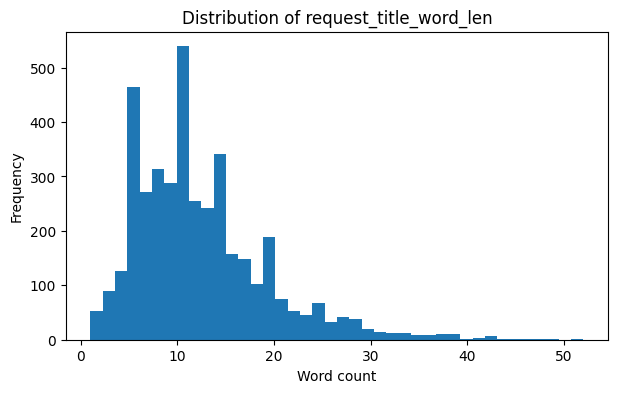

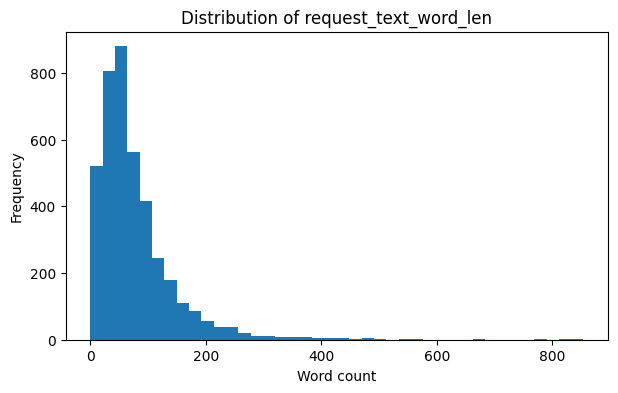

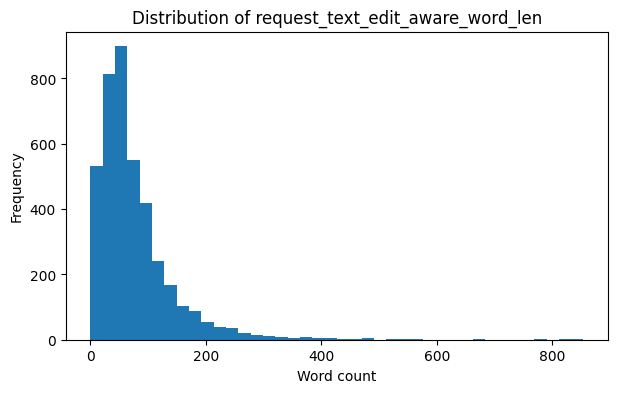

In [ ]:
for col in [c for c in eda_len_cols if c.endswith("_word_len")]:
    plt.figure(figsize=(7, 4))
    plt.hist(train_df[col].fillna(0), bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Word count")
    plt.ylabel("Frequency")
    plt.show()

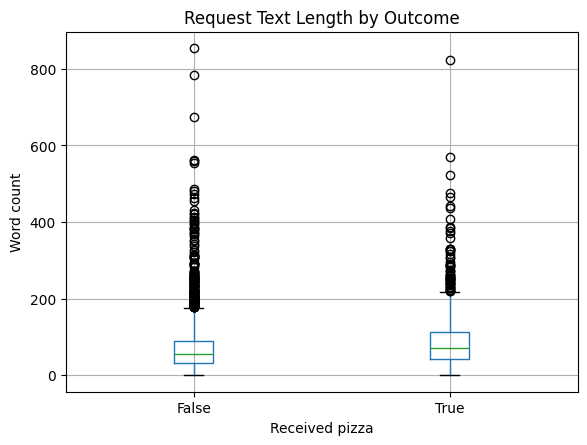

In [ ]:
if "request_text_edit_aware_word_len" in train_df.columns:
    train_df.boxplot(column="request_text_edit_aware_word_len", by=TARGET)
    plt.title("Request Text Length by Outcome")
    plt.suptitle("")
    plt.xlabel("Received pizza")
    plt.ylabel("Word count")
    plt.show()

In [ ]:
safe_numeric_candidates = [
    c for c in train_df.columns
    if (
        (pd.api.types.is_numeric_dtype(train_df[c]) or pd.api.types.is_bool_dtype(train_df[c]))
        and c != TARGET
        and c not in cols_to_drop
        and not c.endswith("_at_retrieval")
    )
]

safe_numeric_candidates

['requester_account_age_in_days_at_request',
 'requester_days_since_first_post_on_raop_at_request',
 'requester_number_of_comments_at_request',
 'requester_number_of_comments_in_raop_at_request',
 'requester_number_of_posts_at_request',
 'requester_number_of_posts_on_raop_at_request',
 'requester_number_of_subreddits_at_request',
 'requester_upvotes_minus_downvotes_at_request',
 'requester_upvotes_plus_downvotes_at_request',
 'unix_timestamp_of_request',
 'unix_timestamp_of_request_utc',
 'request_title_char_len',
 'request_title_word_len',
 'request_text_char_len',
 'request_text_word_len',
 'request_text_edit_aware_char_len',
 'request_text_edit_aware_word_len']

In [ ]:
safe_numeric_candidates = [
    c for c in train_df.columns
    if (
        (pd.api.types.is_numeric_dtype(train_df[c]) or pd.api.types.is_bool_dtype(train_df[c]))
        and c != TARGET
        and c not in cols_to_drop
        and not c.endswith("_at_retrieval")
    )
]

safe_numeric_candidates

['requester_account_age_in_days_at_request',
 'requester_days_since_first_post_on_raop_at_request',
 'requester_number_of_comments_at_request',
 'requester_number_of_comments_in_raop_at_request',
 'requester_number_of_posts_at_request',
 'requester_number_of_posts_on_raop_at_request',
 'requester_number_of_subreddits_at_request',
 'requester_upvotes_minus_downvotes_at_request',
 'requester_upvotes_plus_downvotes_at_request',
 'unix_timestamp_of_request',
 'unix_timestamp_of_request_utc',
 'request_title_char_len',
 'request_title_word_len',
 'request_text_char_len',
 'request_text_word_len',
 'request_text_edit_aware_char_len',
 'request_text_edit_aware_word_len']

In [ ]:
corr_df = train_df[safe_numeric_candidates + [TARGET]].copy()

for col in corr_df.columns:
    if pd.api.types.is_bool_dtype(corr_df[col]):
        corr_df[col] = corr_df[col].astype(int)

corr_with_target = corr_df.corr(numeric_only=True)[TARGET].sort_values(ascending=False)
corr_with_target

requester_received_pizza                              1.000000
requester_number_of_posts_on_raop_at_request          0.137208
requester_number_of_comments_in_raop_at_request       0.131296
request_text_char_len                                 0.126241
request_text_word_len                                 0.122055
request_text_edit_aware_char_len                      0.115881
request_text_edit_aware_word_len                      0.113363
requester_days_since_first_post_on_raop_at_request    0.098225
requester_account_age_in_days_at_request              0.041784
requester_number_of_subreddits_at_request             0.037647
requester_number_of_comments_at_request               0.033779
requester_upvotes_minus_downvotes_at_request          0.032571
requester_upvotes_plus_downvotes_at_request           0.026102
requester_number_of_posts_at_request                  0.020612
request_title_word_len                                0.015680
request_title_char_len                                0

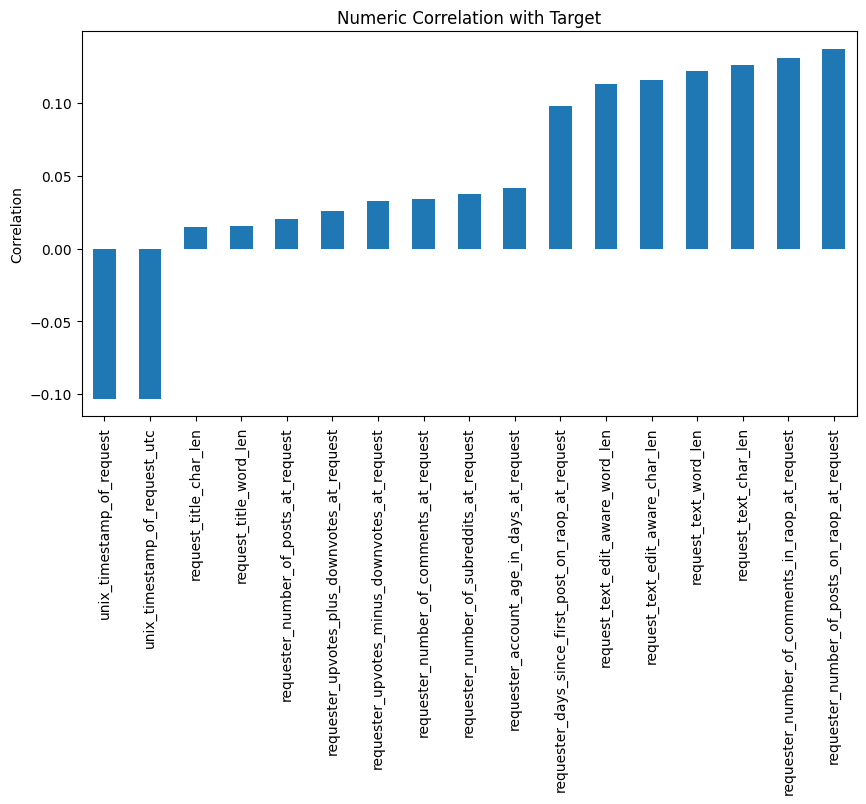

In [ ]:
corr_plot = corr_with_target.drop(index=TARGET, errors="ignore")

plt.figure(figsize=(10, 5))
corr_plot.sort_values().plot(kind="bar")
plt.title("Numeric Correlation with Target")
plt.ylabel("Correlation")
plt.show()

In [ ]:
def add_time_features(df):
    df = df.copy()
    if "unix_timestamp_of_request_utc" in df.columns:
        ts = pd.to_datetime(df["unix_timestamp_of_request_utc"], unit="s", errors="coerce", utc=True)
        df["request_hour_utc"] = ts.dt.hour
        df["request_dayofweek_utc"] = ts.dt.dayofweek
        df["request_month_utc"] = ts.dt.month
        df["request_year_utc"] = ts.dt.year
        df["is_weekend_utc"] = ts.dt.dayofweek.isin([5, 6]).astype(int)
    return df

train_df = add_time_features(train_df)
if test_df is not None:
    test_df = add_time_features(test_df)

train_df[[c for c in ["request_hour_utc", "request_dayofweek_utc", "request_month_utc", "request_year_utc", "is_weekend_utc"] if c in train_df.columns]].head()

,request_hour_utc,request_dayofweek_utc,request_month_utc,request_year_utc,is_weekend_utc
0,21,2,10,2011,0
1,4,6,3,2012,1
2,16,2,10,2011,0
3,19,4,12,2011,0
4,18,4,7,2013,0


In [ ]:
preferred_text_col = "request_text_edit_aware" if "request_text_edit_aware" in train_df.columns else "request_text"
title_col = "request_title" if "request_title" in train_df.columns else None
subreddit_list_col = "requester_subreddits_at_request" if "requester_subreddits_at_request" in train_df.columns else None

feature_df = train_df.copy()

if subreddit_list_col is not None:
    feature_df["requester_subreddits_list_count"] = feature_df[subreddit_list_col].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )

feature_df["combined_text"] = ""
if title_col:
    feature_df["combined_text"] += " " + feature_df[title_col].fillna("")
if preferred_text_col:
    feature_df["combined_text"] += " " + feature_df[preferred_text_col].fillna("")
feature_df["combined_text"] = feature_df["combined_text"].str.strip()

base_drop_cols = set(cols_to_drop + [TARGET, "request_text", "request_text_edit_aware", "request_title"])
if subreddit_list_col:
    base_drop_cols.add(subreddit_list_col)

X_full = feature_df.drop(columns=[c for c in base_drop_cols if c in feature_df.columns], errors="ignore")
y = feature_df[TARGET].astype(int)

text_features = ["combined_text"]
numeric_features = [
    c for c in X_full.columns
    if c not in text_features
    and (pd.api.types.is_numeric_dtype(X_full[c]) or pd.api.types.is_bool_dtype(X_full[c]))
]
categorical_features = [
    c for c in X_full.columns
    if c not in text_features + numeric_features
]

print("Text features:", text_features)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("X shape:", X_full.shape)

Text features: ['combined_text']
Numeric features: ['requester_account_age_in_days_at_request', 'requester_days_since_first_post_on_raop_at_request', 'requester_number_of_comments_at_request', 'requester_number_of_comments_in_raop_at_request', 'requester_number_of_posts_at_request', 'requester_number_of_posts_on_raop_at_request', 'requester_number_of_subreddits_at_request', 'requester_upvotes_minus_downvotes_at_request', 'requester_upvotes_plus_downvotes_at_request', 'unix_timestamp_of_request', 'unix_timestamp_of_request_utc', 'request_title_char_len', 'request_title_word_len', 'request_text_char_len', 'request_text_word_len', 'request_text_edit_aware_char_len', 'request_text_edit_aware_word_len', 'request_hour_utc', 'request_dayofweek_utc', 'request_month_utc', 'request_year_utc', 'is_weekend_utc', 'requester_subreddits_list_count']
Categorical features: ['post_was_edited']
X shape: (4040, 25)


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_full,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train split:", X_train.shape, y_train.shape)
print("Valid split:", X_valid.shape, y_valid.shape)

Train split: (3232, 25) (3232,)
Valid split: (808, 25) (808,)


In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

text_transformer = Pipeline(
    steps=[
        ("selector", FunctionTransformer(lambda x: x.squeeze(), validate=False)),
        (
            "tfidf",
            TfidfVectorizer(
                stop_words="english",
                ngram_range=(1, 2),
                min_df=3,
                max_df=0.95,
                strip_accents="unicode",
                sublinear_tf=True,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_transformer, text_features),
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

baseline_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", baseline_model),
    ]
)

clf

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_results = cross_validate(clf, X_full, y, cv=cv, scoring=scoring, return_train_score=False)
cv_results

{'fit_time': array([12.23653078,  5.02530575,  4.80433941,  4.8808887 ,  4.75437307]),
 'score_time': array([0.11311102, 0.15483475, 0.15839791, 0.14654326, 0.14501619]),
 'test_accuracy': array([0.71163366, 0.66336634, 0.6980198 , 0.69183168, 0.6720297 ]),
 'test_f1': array([0.46681922, 0.39823009, 0.45535714, 0.41686183, 0.40180587]),
 'test_roc_auc': array([0.68661202, 0.63257998, 0.67580926, 0.64594731, 0.64857951])}

In [ ]:
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric}: mean={scores.mean():.4f}, std={scores.std():.4f}, scores={np.round(scores, 4)}")

accuracy: mean=0.6874, std=0.0175, scores=[0.7116 0.6634 0.698  0.6918 0.672 ]
f1: mean=0.4278, std=0.0281, scores=[0.4668 0.3982 0.4554 0.4169 0.4018]
roc_auc: mean=0.6579, std=0.0201, scores=[0.6866 0.6326 0.6758 0.6459 0.6486]


In [ ]:
clf.fit(X_train, y_train)
valid_pred = clf.predict(X_valid)
valid_prob = clf.predict_proba(X_valid)[:, 1]

print("Validation Accuracy:", round(accuracy_score(y_valid, valid_pred), 4))
print("Validation F1:", round(f1_score(y_valid, valid_pred), 4))
print("Validation ROC-AUC:", round(roc_auc_score(y_valid, valid_prob), 4))

Validation Accuracy: 0.6609
Validation F1: 0.4069
Validation ROC-AUC: 0.6452


In [ ]:
print(classification_report(y_valid, valid_pred, digits=4))

              precision    recall  f1-score   support

           0     0.8073    0.7225    0.7626       609
           1     0.3574    0.4724    0.4069       199

    accuracy                         0.6609       808
   macro avg     0.5824    0.5974    0.5847       808
weighted avg     0.6965    0.6609    0.6750       808



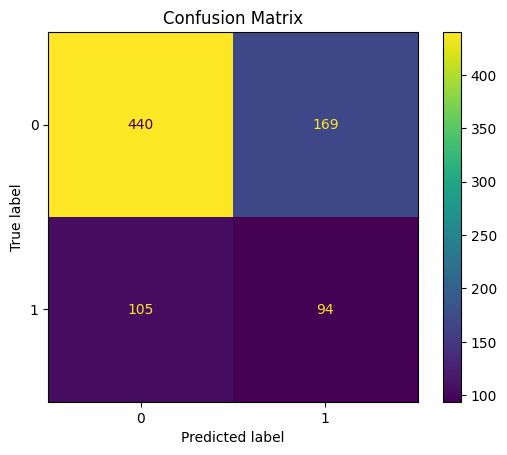

In [ ]:
cm = confusion_matrix(y_valid, valid_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix")
plt.show()

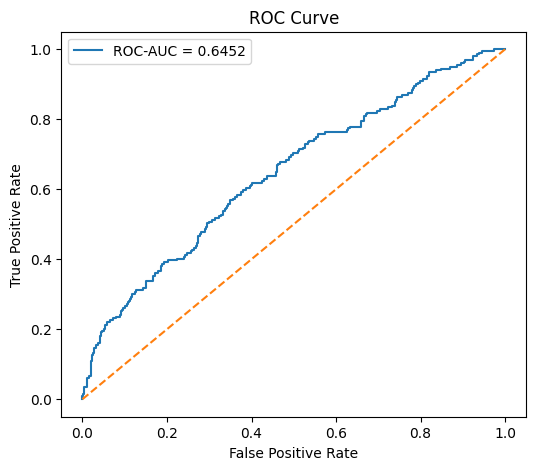

In [ ]:
fpr, tpr, _ = roc_curve(y_valid, valid_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_valid, valid_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

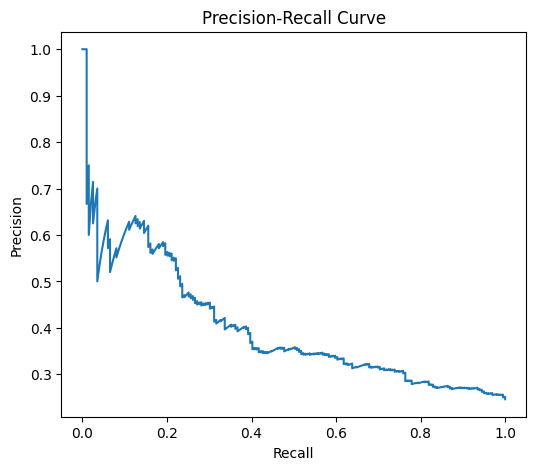

In [ ]:
precision, recall, _ = precision_recall_curve(y_valid, valid_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
analysis_cols = [
    c for c in [
        "requester_account_age_in_days_at_request",
        "requester_number_of_comments_at_request",
        "requester_number_of_posts_at_request",
        "requester_number_of_subreddits_at_request",
        "requester_number_of_comments_in_raop_at_request",
        "requester_number_of_posts_on_raop_at_request",
        "requester_days_since_first_post_on_raop_at_request",
        "requester_upvotes_minus_downvotes_at_request",
        "requester_upvotes_plus_downvotes_at_request",
        "request_hour_utc",
        "request_dayofweek_utc",
        "request_text_edit_aware_word_len",
        "request_title_word_len",
    ] if c in train_df.columns
]

analysis_cols

['requester_account_age_in_days_at_request',
 'requester_number_of_comments_at_request',
 'requester_number_of_posts_at_request',
 'requester_number_of_subreddits_at_request',
 'requester_number_of_comments_in_raop_at_request',
 'requester_number_of_posts_on_raop_at_request',
 'requester_days_since_first_post_on_raop_at_request',
 'requester_upvotes_minus_downvotes_at_request',
 'requester_upvotes_plus_downvotes_at_request',
 'request_hour_utc',
 'request_dayofweek_utc',
 'request_text_edit_aware_word_len',
 'request_title_word_len']

<Figure size 700x400 with 0 Axes>

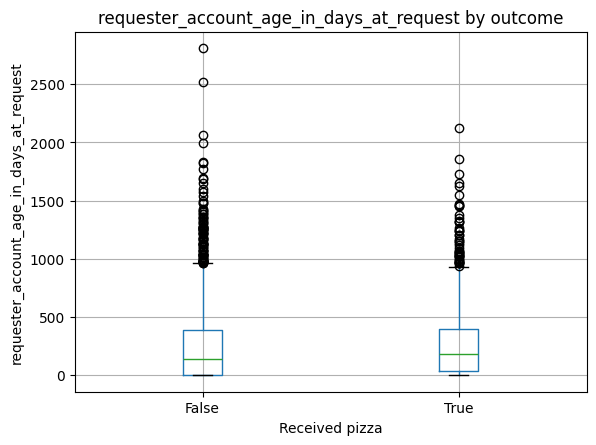

<Figure size 700x400 with 0 Axes>

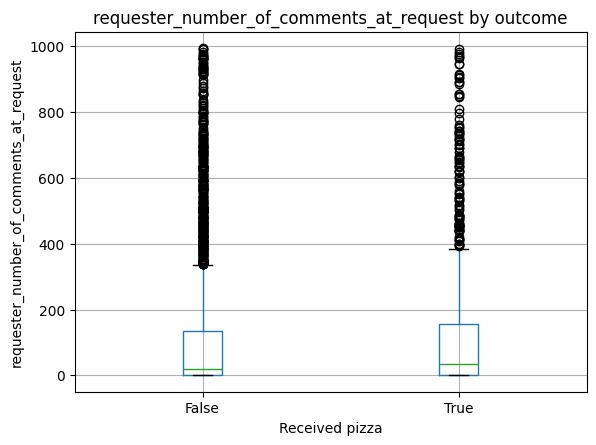

<Figure size 700x400 with 0 Axes>

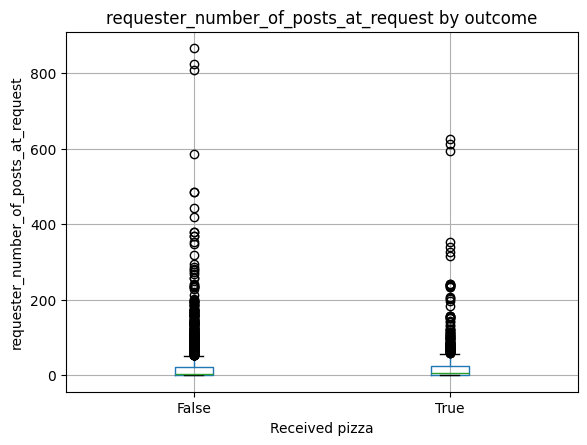

<Figure size 700x400 with 0 Axes>

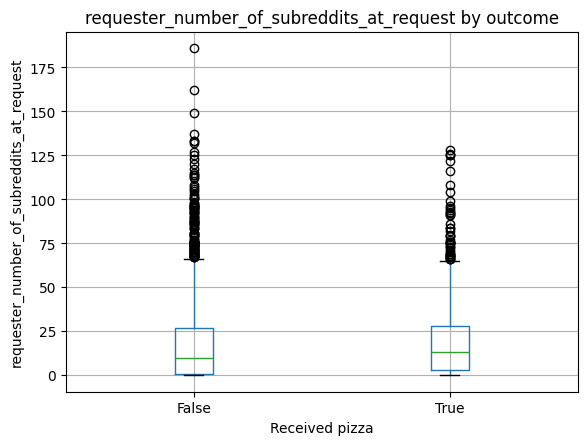

<Figure size 700x400 with 0 Axes>

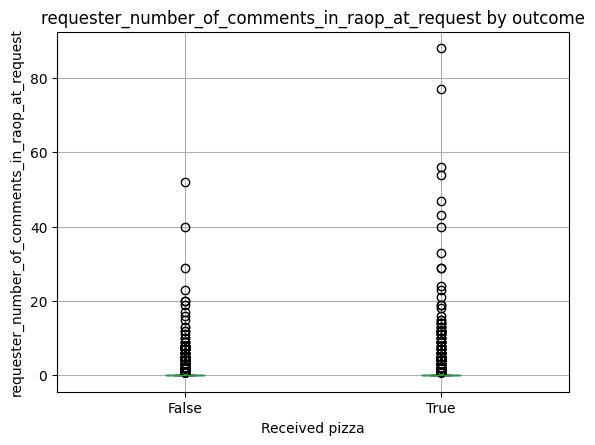

<Figure size 700x400 with 0 Axes>

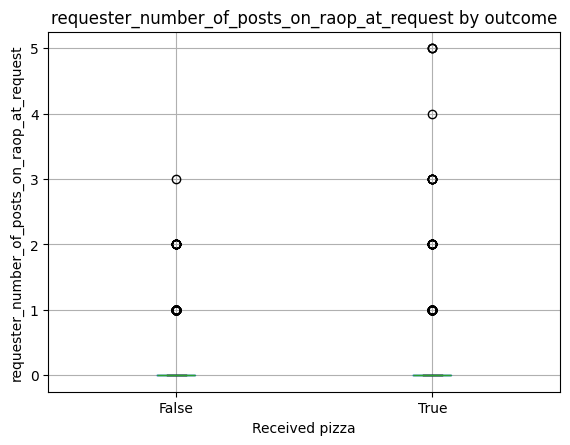

<Figure size 700x400 with 0 Axes>

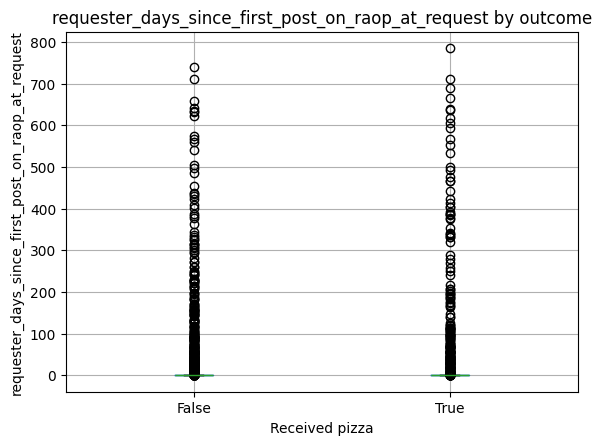

<Figure size 700x400 with 0 Axes>

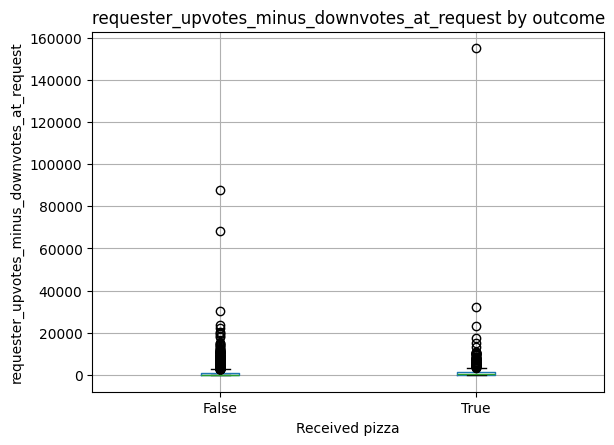

<Figure size 700x400 with 0 Axes>

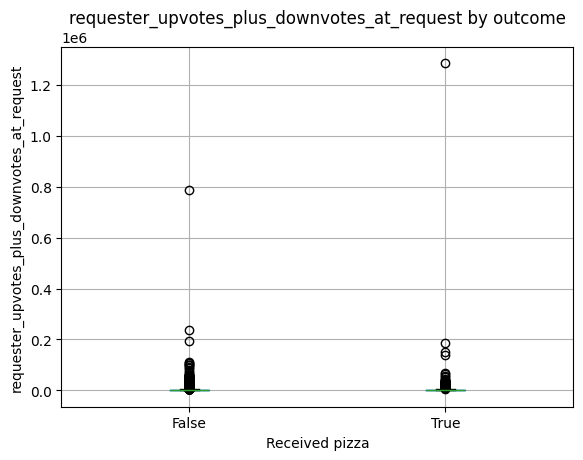

<Figure size 700x400 with 0 Axes>

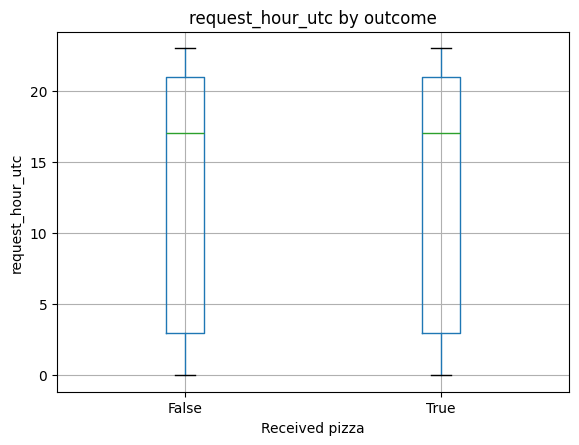

<Figure size 700x400 with 0 Axes>

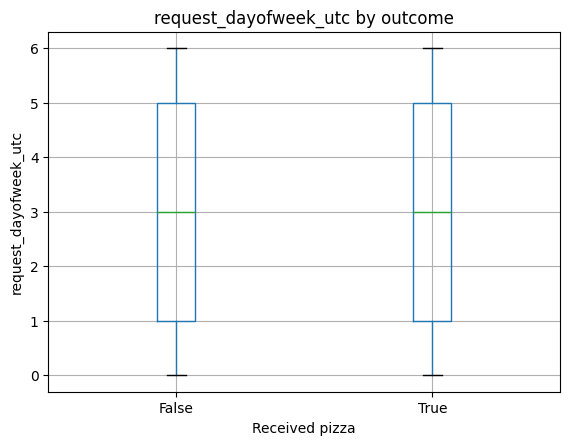

<Figure size 700x400 with 0 Axes>

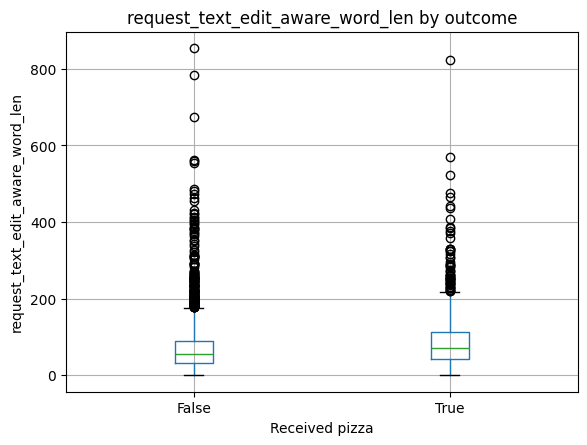

<Figure size 700x400 with 0 Axes>

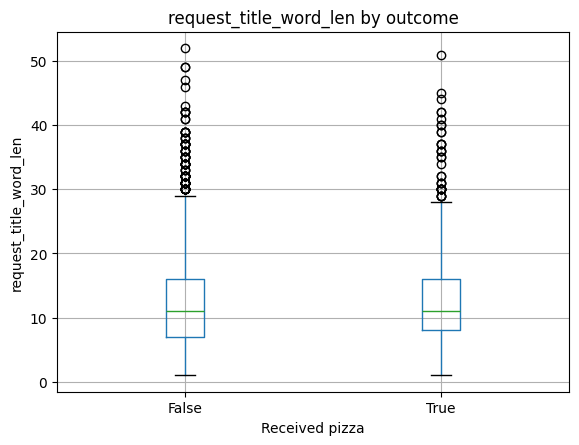

In [ ]:
for col in analysis_cols:
    plt.figure(figsize=(7, 4))
    train_df.boxplot(column=col, by=TARGET)
    plt.title(f"{col} by outcome")
    plt.suptitle("")
    plt.xlabel("Received pizza")
    plt.ylabel(col)
    plt.show()

In [ ]:
# Cell 32: Safely extract feature names and coefficients
fitted_preprocessor = clf.named_steps["preprocessor"]
fitted_model = clf.named_steps["model"]

try:
    feature_names = fitted_preprocessor.get_feature_names_out()
except:
    text_pipe = fitted_preprocessor.named_transformers_["text"]
    text_vectorizer = text_pipe.named_steps["tfidf"]
    text_names = np.array([f"text__{name}" for name in text_vectorizer.get_feature_names_out()])

    num_names = np.array([f"num__{name}" for name in numeric_features])

    if len(categorical_features) > 0:
        cat_encoder = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = cat_encoder.get_feature_names_out(categorical_features)
        cat_names = np.array([f"cat__{name}" for name in cat_names])
    else:
        cat_names = np.array([])

    feature_names = np.concatenate([text_names, num_names, cat_names])

coefs = fitted_model.coef_.ravel()
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})

print("Number of feature names:", len(feature_names))
print("Number of coefficients:", len(coefs))
coef_df.head()

Number of feature names: 9749
Number of coefficients: 9749


,feature,coef
0,text__00,-0.006583
1,text__00 pm,0.379886
2,text__000,0.000687
3,text__05,0.119741
4,text__10,0.469173


In [ ]:
coef_df.sort_values("coef", ascending=False).head(20)

,feature,coef
7157,text__rice,1.410396
5779,text__paycheck,1.355379
6704,text__recently,1.326237
8836,text__ve,1.312598
8074,text__surprise,1.263103
8505,text__tonight,1.262088
1576,text__daughter,1.236543
9166,text__weeks,1.159802
1529,text__currently,1.153403
1626,text__days,1.107702


In [ ]:
coef_df.sort_values("coef", ascending=True).head(20)

,feature,coef
2766,text__friend,-1.387606
7332,text__say,-1.066172
2783,text__friends,-1.049289
3651,text__house,-1.012007
431,text__area,-1.007298
9018,text__want pizza,-0.937280
2473,text__final,-0.907696
2930,text__girlfriend,-0.894263
3013,text__good,-0.838722
2061,text__eat,-0.820011
